# Acte 4 — Agir

## Objectif de ce notebook

On va utiliser le world model entraîné pour **agir** dans le monde —
c'est-à-dire planifier une séquence d'actions qui amène la boîte
sur la cible.

On procède en deux étapes :

1. **Rollout multi-step** : vérifier que le modèle peut imaginer
   une séquence de futurs états sans s'effondrer
2. **Planning** : chercher la séquence d'actions qui minimise
   la distance latente entre l'état final prédit et l'état objectif

## Lien avec le papier LeWM

C'est la section 4 du papier — "Latent Planning Performance".
LeWM planifie avec CEM (Cross-Entropy Method) dans l'espace latent,
exactement comme on va le faire ici.

## Ce qu'on ne fait pas ici

On n'entraîne pas le modèle davantage. On ne lui donne pas
d'informations sur l'objectif pendant l'entraînement.
Le world model reste figé — seule la planification change.

## Imports et chargement du modèle

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

import sys
import os
sys.path.append(os.path.abspath(".."))

from environment import GridWorld
from model import WorldModel

# Chargement du modèle entraîné
model = WorldModel(latent_dim=32)
model.load_state_dict(torch.load("../data/worldmodel.pt"))
model.eval()

print("Modèle chargé")
print(f"Nombre de paramètres : {sum(p.numel() for p in model.parameters()):,}")

Modèle chargé
Nombre de paramètres : 117,824


## 1. Rollout multi-step

### Objectif

Vérifier que le modèle peut imaginer une séquence de futurs états
sans s'effondrer — c'est la condition nécessaire pour planifier.

### Méthode

On part d'un état réel, on donne une séquence d'actions au modèle,
et on le laisse prédire les états futurs en boucle ouverte :
```text
z_0 → z_1 → z_2 → ... → z_H
```

À chaque pas, le prédicteur utilise le latent prédit au pas précédent
— jamais l'état réel. C'est ce qui distingue le rollout du simple
one-step : les erreurs s'accumulent.

### Ce qu'on mesure

L'erreur de prédiction à chaque horizon — distance entre le latent
prédit et le latent réel de l'état correspondant. Si le modèle est
bon, cette erreur doit rester faible sur les premiers pas et
augmenter progressivement sur les pas lointains.

In [3]:
def rollout(model, obs_sequence, action_sequence):
    """
    Effectue un rollout multi-step en boucle ouverte.
    
    Paramètres :
        model          : WorldModel entraîné
        obs_sequence   : (H+1, 10, 10) numpy array — états réels
        action_sequence: (H,) numpy array — actions
    
    Retourne :
        z_real : (H+1, latent_dim) — latents réels encodés
        z_pred : (H+1, latent_dim) — latents prédits en boucle ouverte
        errors : (H,) — erreur MSE à chaque pas
    """
    model.eval()
    H = len(action_sequence)

    with torch.no_grad():
        # Encodage de tous les états réels
        obs_tensor = torch.tensor(
            obs_sequence, dtype=torch.float32
        ).unsqueeze(1)  # (H+1, 1, 10, 10)
        z_real = model.encoder(obs_tensor).numpy()  # (H+1, latent_dim)

        # Rollout en boucle ouverte
        z_pred = np.zeros_like(z_real)
        z_pred[0] = z_real[0]  # état initial réel

        for t in range(H):
            z_t = torch.tensor(z_pred[t], dtype=torch.float32).unsqueeze(0)
            a_t = torch.tensor([action_sequence[t]], dtype=torch.long)
            a_emb = model.action_encoder(a_t)
            z_next = model.predictor(z_t, a_emb)
            z_pred[t+1] = z_next.numpy()

    # Erreur MSE à chaque pas
    errors = np.mean((z_pred[1:] - z_real[1:]) ** 2, axis=1)

    return z_real, z_pred, errors

### Test du rollout sur une trajectoire réelle

On génère une trajectoire en laissant l'agent agir aléatoirement,
puis on compare les états prédits par le modèle aux états réels.

In [4]:
# Génération d'une trajectoire réelle
H = 20  # horizon de 20 pas

env = GridWorld()
env.reset()

obs_sequence    = [env.render().copy()]
action_sequence = []

for t in range(H):
    action = np.random.randint(0, 4)
    obs_next = env.step(action)
    obs_sequence.append(obs_next.copy())
    action_sequence.append(action)

obs_sequence    = np.array(obs_sequence,    dtype=np.float32)
action_sequence = np.array(action_sequence, dtype=np.int64)

print(f"Longueur trajectoire : {len(obs_sequence)} états, {len(action_sequence)} actions")

# Rollout
z_real, z_pred, errors = rollout(model, obs_sequence, action_sequence)

print(f"Shape z_real : {z_real.shape}")
print(f"Shape z_pred : {z_pred.shape}")
print(f"Erreur moyenne : {errors.mean():.4f}")
print(f"Erreur max     : {errors.max():.4f}")

Longueur trajectoire : 21 états, 20 actions
Shape z_real : (21, 32)
Shape z_pred : (21, 32)
Erreur moyenne : 0.0113
Erreur max     : 0.0305


### Erreur de rollout en fonction de l'horizon

On s'attend à voir une erreur qui augmente avec l'horizon —
les erreurs s'accumulent pas à pas. Si la courbe est plate,
le modèle est très robuste. Si elle explose, le modèle dérive.

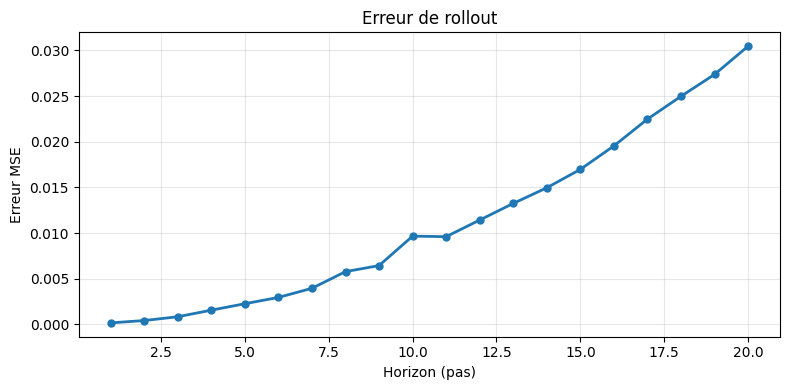

Visuel sauvegardé dans assets/


In [5]:
def plot_rollout_errors(errors, title="Erreur de rollout"):
    """Affiche l'erreur MSE en fonction de l'horizon de prédiction."""
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(range(1, len(errors) + 1), errors,
            marker="o", linewidth=2, markersize=5)
    ax.set_xlabel("Horizon (pas)")
    ax.set_ylabel("Erreur MSE")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("../assets/04_rollout_errors.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Visuel sauvegardé dans assets/")

plot_rollout_errors(errors)

## 2. Planning par recherche exhaustive

### Objectif

Trouver la séquence d'actions qui amène la boîte sur la cible
en simulant toutes les séquences possibles jusqu'à un horizon H.

### Méthode

1. Encoder l'état initial et l'état objectif
2. Générer toutes les séquences d'actions possibles (4^H séquences)
3. Simuler chaque séquence avec le modèle (rollout)
4. Mesurer le coût : distance latente entre état final prédit et objectif
5. Choisir la séquence avec le coût minimal

### Pourquoi cette méthode d'abord ?

C'est la plus simple et la plus lisible. Elle garantit de trouver
la meilleure séquence possible à l'horizon H — au prix d'un coût
exponentiel en H. Pour H=5 : 4^5 = 1024 séquences à tester.
C'est faisable sur CPU en quelques secondes.

In [7]:
import itertools

def plan_exhaustive(model, obs_init, obs_goal, horizon=5):
    """
    Planning par recherche exhaustive.
    Teste toutes les séquences d'actions possibles jusqu'à l'horizon H
    et retourne la meilleure.
    
    Paramètres :
        model    : WorldModel entraîné
        obs_init : (10, 10) numpy array — état initial
        obs_goal : (10, 10) numpy array — état objectif
        horizon  : int — longueur des séquences testées
    
    Retourne :
        best_seq  : liste d'actions — meilleure séquence trouvée
        best_cost : float — coût de la meilleure séquence
        all_costs : liste de tous les coûts (pour analyse)
    """
    model.eval()

    with torch.no_grad():
        # Encodage de l'état initial et de l'objectif
        z_init = model.encoder(
            torch.tensor(obs_init, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
        )  # (1, latent_dim)

        z_goal = model.encoder(
            torch.tensor(obs_goal, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
        )  # (1, latent_dim)

        best_seq  = None
        best_cost = float("inf")
        all_costs = []

        # Génération de toutes les séquences possibles
        for seq in itertools.product(range(4), repeat=horizon):
            # Rollout de la séquence
            z = z_init.clone()
            for action in seq:
                a = torch.tensor([action], dtype=torch.long)
                a_emb = model.action_encoder(a)
                z = model.predictor(z, a_emb)

            # Coût : distance latente à l'objectif
            cost = torch.mean((z - z_goal) ** 2).item()
            all_costs.append(cost)

            if cost < best_cost:
                best_cost = cost
                best_seq  = list(seq)

    return best_seq, best_cost, all_costs


ACTION_NAMES = {0: "haut", 1: "bas", 2: "gauche", 3: "droite"}

### Scénario de test

On crée une situation simple où la boîte est proche de la cible
pour maximiser les chances de succès avec un horizon court.

L'état objectif est la configuration où la boîte est sur la cible.

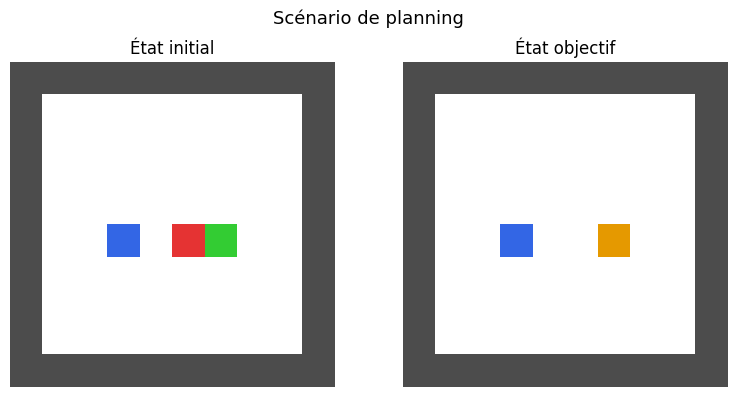

In [9]:
# Création du scénario
env = GridWorld()

# État initial : agent à gauche de la boîte, boîte proche de la cible
env.agent  = (5, 3)
env.box    = (5, 5)
env.target = (5, 6)

obs_init = env.render().copy()

# État objectif : boîte sur la cible
env_goal = GridWorld()
env_goal.agent  = (5, 3)  # position agent peu importe
env_goal.box    = (5, 6)  # boîte SUR la cible
env_goal.target = (5, 6)

obs_goal = env_goal.render().copy()

# Visualisation du scénario
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

for ax, grid, title in zip(
    axes,
    [obs_init, obs_goal],
    ["État initial", "État objectif"]
):
    rgb = np.zeros((10, 10, 3), dtype=np.float64)
    rgb[grid == GridWorld.EMPTY]           = [1.0, 1.0, 1.0]
    rgb[grid == GridWorld.WALL]            = [0.3, 0.3, 0.3]
    rgb[grid == GridWorld.AGENT]           = [0.2, 0.4, 0.9]
    rgb[grid == GridWorld.BOX]             = [0.9, 0.2, 0.2]
    rgb[grid == GridWorld.TARGET]          = [0.2, 0.8, 0.2]
    rgb[grid == GridWorld.BOX_ON_TARGET]   = [0.9, 0.6, 0.0]
    rgb[grid == GridWorld.AGENT_ON_TARGET] = [0.4, 0.2, 0.9]
    rgb[grid == GridWorld.AGENT_ON_BOX]    = [0.9, 0.5, 0.0]
    ax.imshow(rgb)
    ax.set_title(title)
    ax.axis("off")

plt.suptitle("Scénario de planning", fontsize=13)
plt.tight_layout()
plt.show()

### Lancement du planning exhaustif

On teste toutes les séquences de longueur H=5.
La solution évidente est [droite, droite] —
on va voir si le modèle la trouve.

In [10]:
# Planning
best_seq, best_cost, all_costs = plan_exhaustive(
    model, obs_init, obs_goal, horizon=5
)

print(f"Nombre de séquences testées : {len(all_costs)}")
print(f"Meilleur coût               : {best_cost:.4f}")
print(f"Meilleure séquence          : {[ACTION_NAMES[a] for a in best_seq]}")
print(f"Coût moyen                  : {np.mean(all_costs):.4f}")
print(f"Coût min                    : {np.min(all_costs):.4f}")
print(f"Coût max                    : {np.max(all_costs):.4f}")

Nombre de séquences testées : 1024
Meilleur coût               : 0.0043
Meilleure séquence          : ['gauche', 'bas', 'bas', 'bas', 'bas']
Coût moyen                  : 0.0049
Coût min                    : 0.0043
Coût max                    : 0.0059


In [11]:
# diag

# Diagnostic : que contient l'état objectif ?
print(f"Valeurs uniques dans obs_goal : {np.unique(obs_goal)}")
print(f"Valeur pixel boîte/cible      : {obs_goal[env_goal.target]}")

# Distance latente entre init et goal
z_init_t = model.encoder(
    torch.tensor(obs_init, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
)
z_goal_t = model.encoder(
    torch.tensor(obs_goal, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
)
dist = torch.mean((z_init_t - z_goal_t) ** 2).item()
print(f"Distance latente init → goal  : {dist:.4f}")

Valeurs uniques dans obs_goal : [0.  0.3 0.5 0.9]
Valeur pixel boîte/cible      : 0.9
Distance latente init → goal  : 0.0035


### V1 — Planning avec états objectifs multiples

Le latent encode mal les positions absolues — comparer un seul état
"boîte sur cible" ne donne pas un signal assez fort pour guider
le planning.

Solution V1 : on génère plusieurs états objectifs autour de la cible
(boîte à 1 case dans chaque direction) et on prend le minimum
des distances latentes. Ça élargit le signal et le rend plus robuste.

In [12]:
def make_goal_states(env_config, target_pos):
    """
    Génère plusieurs états objectifs autour de la cible.
    
    On place la boîte à la position cible et dans les 4 cases
    adjacentes — ça donne un signal plus large pour le planning.
    
    Paramètres :
        env_config : dict avec agent, box, target
        target_pos : tuple (r, c) — position de la cible
    
    Retourne :
        goal_states : liste de numpy arrays 10×10
    """
    goal_states = []

    # Positions à tester : cible + 4 cases adjacentes
    candidates = [
        target_pos,
        (target_pos[0] - 1, target_pos[1]),
        (target_pos[0] + 1, target_pos[1]),
        (target_pos[0], target_pos[1] - 1),
        (target_pos[0], target_pos[1] + 1),
    ]

    env_g = GridWorld()
    env_g.agent  = env_config["agent"]
    env_g.target = target_pos

    for pos in candidates:
        # Vérifier que la position est dans l'intérieur
        if not (1 <= pos[0] <= 8 and 1 <= pos[1] <= 8):
            continue
        env_g.box = pos
        goal_states.append(env_g.render().copy())

    return goal_states


def plan_exhaustive_v2(model, obs_init, goal_states, horizon=5):
    """
    Planning exhaustif avec plusieurs états objectifs.
    
    Le coût d'une séquence est le minimum des distances latentes
    à tous les états objectifs.
    
    Paramètres :
        model       : WorldModel entraîné
        obs_init    : (10, 10) numpy array — état initial
        goal_states : liste de numpy arrays — états objectifs
        horizon     : int — longueur des séquences
    
    Retourne :
        best_seq  : meilleure séquence d'actions
        best_cost : coût minimal trouvé
        all_costs : tous les coûts
    """
    model.eval()

    with torch.no_grad():
        # Encodage de l'état initial
        z_init = model.encoder(
            torch.tensor(obs_init, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
        )

        # Encodage de tous les états objectifs
        z_goals = []
        for gs in goal_states:
            z_g = model.encoder(
                torch.tensor(gs, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
            )
            z_goals.append(z_g)

        best_seq  = None
        best_cost = float("inf")
        all_costs = []

        for seq in itertools.product(range(4), repeat=horizon):
            # Rollout
            z = z_init.clone()
            for action in seq:
                a     = torch.tensor([action], dtype=torch.long)
                a_emb = model.action_encoder(a)
                z     = model.predictor(z, a_emb)

            # Coût = minimum des distances à tous les objectifs
            cost = min(
                torch.mean((z - z_g) ** 2).item()
                for z_g in z_goals
            )
            all_costs.append(cost)

            if cost < best_cost:
                best_cost = cost
                best_seq  = list(seq)

    return best_seq, best_cost, all_costs

### Lancement du planning V1

In [13]:
# Génération des états objectifs autour de la cible
goal_states = make_goal_states(
    env_config={"agent": (5, 3), "box": (5, 5)},
    target_pos=(5, 6)
)
print(f"Nombre d'états objectifs : {len(goal_states)}")

# Planning
best_seq, best_cost, all_costs = plan_exhaustive_v2(
    model, obs_init, goal_states, horizon=5
)

print(f"\nNombre de séquences testées : {len(all_costs)}")
print(f"Meilleur coût               : {best_cost:.4f}")
print(f"Meilleure séquence          : {[ACTION_NAMES[a] for a in best_seq]}")

Nombre d'états objectifs : 5

Nombre de séquences testées : 1024
Meilleur coût               : 0.0018
Meilleure séquence          : ['haut', 'gauche', 'gauche', 'bas', 'bas']


In [14]:
# Simulation de la séquence trouvée dans le monde réel
env_test = GridWorld()
env_test.agent  = (5, 3)
env_test.box    = (5, 5)
env_test.target = (5, 6)

print("État initial :")
print(f"  agent : {env_test.agent}")
print(f"  boîte : {env_test.box}")
print(f"  cible : {env_test.target}")
print()

for i, action in enumerate(best_seq):
    env_test.step(action)
    print(f"Action {i+1} — {ACTION_NAMES[action]}")
    print(f"  agent : {env_test.agent}")
    print(f"  boîte : {env_test.box}")

print()
if env_test.box == env_test.target:
    print("✅ Boîte sur la cible — SUCCÈS !")
else:
    dist = abs(env_test.box[0] - env_test.target[0]) + \
           abs(env_test.box[1] - env_test.target[1])
    print(f"❌ Boîte pas sur la cible — distance Manhattan : {dist}")

État initial :
  agent : (5, 3)
  boîte : (5, 5)
  cible : (5, 6)

Action 1 — haut
  agent : (4, 3)
  boîte : (5, 5)
Action 2 — gauche
  agent : (4, 2)
  boîte : (5, 5)
Action 3 — gauche
  agent : (4, 1)
  boîte : (5, 5)
Action 4 — bas
  agent : (5, 1)
  boîte : (5, 5)
Action 5 — bas
  agent : (6, 1)
  boîte : (5, 5)

❌ Boîte pas sur la cible — distance Manhattan : 1


### Résultat V1 et analyse

La séquence trouvée déplace l'agent mais ne pousse pas la boîte.
La boîte reste à distance 1 de la cible.

**Pourquoi ça échoue ?**

Le planning minimise la distance latente entre l'état final prédit
et les états objectifs. Mais le latent encode mal les positions
absolues — on l'a mesuré dans l'acte 3 (R² probing ≈ 0).

Le signal de coût n'est pas assez discriminant pour guider
le planning vers la bonne séquence. Toutes les séquences ont
des coûts très proches (0.0018 à ~0.005), ce qui signifie que
le modèle ne "voit" pas vraiment la différence entre
"boîte proche de la cible" et "boîte loin de la cible".

**Ce qu'il faudrait pour la V2**

Un latent qui encode mieux les positions absolues — ce qui
nécessite un dataset avec des trajectoires dirigées plutôt
qu'aléatoires, ou une fonction de coût dans l'espace réel
plutôt que dans l'espace latent.